# FAILSAFE: Model Training & Evaluation

## Cell 1 — Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

In [3]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features')
print(f'Test set:     {X_test.shape[0]} samples, {X_test.shape[1]} features')
print(f'\nTraining labels: Pass={sum(y_train==0)}, At-risk={sum(y_train==1)}')
print(f'Test labels:     Pass={sum(y_test==0)}, At-risk={sum(y_test==1)}')

Training set: 1302 samples, 38 features
Test set:     209 samples, 38 features

Training labels: Pass=651, At-risk=651
Test labels:     Pass=163, At-risk=46


In [15]:
# Baseline model — default hyperparameters
baseline_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]

print('Baseline model trained!')
print(f'\nBaseline Results:')
print(f'  F1 Score (at-risk class): {f1_score(y_test, y_pred_baseline):.4f}')
print(f'  Precision:                {precision_score(y_test, y_pred_baseline):.4f}')
print(f'  Recall:                   {recall_score(y_test, y_pred_baseline):.4f}')
print(f'  AUC-ROC:                  {roc_auc_score(y_test, y_prob_baseline):.4f}')

Baseline model trained!

Baseline Results:
  F1 Score (at-risk class): 0.7957
  Precision:                0.7872
  Recall:                   0.8043
  AUC-ROC:                  0.9661


In [5]:
# This shows WHY accuracy is misleading for imbalanced data
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_baseline)
dummy_accuracy = sum(y_test == 0) / len(y_test)  # Always predict 'pass'

print('Why we do NOT use accuracy as the main metric:')
print(f'  Our model accuracy:           {accuracy:.1%}')
print(f'  Dummy (always predict pass):  {dummy_accuracy:.1%}')
print(f'  Difference:                   {(accuracy - dummy_accuracy):.1%}')
print()
print('Metric definitions:')
print('  Precision = of students we flagged as at-risk, how many actually were?')
print('  Recall    = of all actual at-risk students, how many did we catch?')
print('  F1        = harmonic mean of precision and recall (balances both)')
print('  AUC-ROC   = overall ability to rank at-risk higher than passing students')
print()
print('For FAILSAFE, Recall is most critical:')
print('  Missing an at-risk student (false negative) is worse than a false alarm.')

Why we do NOT use accuracy as the main metric:
  Our model accuracy:           90.9%
  Dummy (always predict pass):  78.0%
  Difference:                   12.9%

Metric definitions:
  Precision = of students we flagged as at-risk, how many actually were?
  Recall    = of all actual at-risk students, how many did we catch?
  F1        = harmonic mean of precision and recall (balances both)
  AUC-ROC   = overall ability to rank at-risk higher than passing students

For FAILSAFE, Recall is most critical:
  Missing an at-risk student (false negative) is worse than a false alarm.


## Confusion Matrix (baseline)

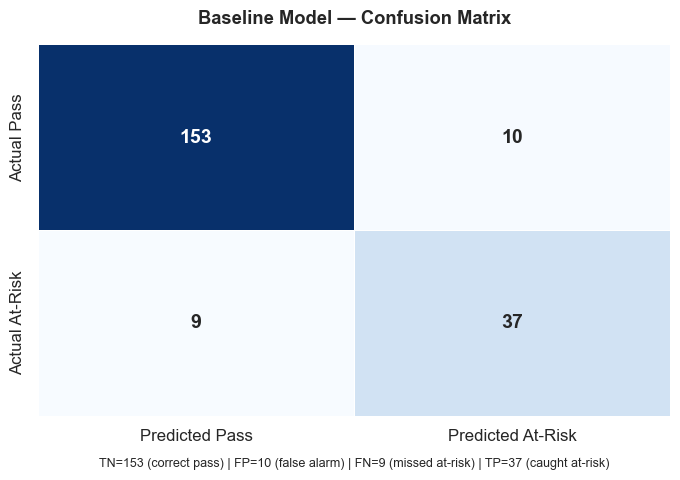

True Negatives  (correctly said pass):     153
False Positives (false alarm — not at risk): 10
False Negatives (missed at-risk student):  9  ← we want this LOW
True Positives  (correctly caught at-risk): 37


In [16]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Pass', 'Predicted At-Risk'],
                yticklabels=['Actual Pass', 'Actual At-Risk'],
                linewidths=0.5, ax=ax, cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    
    ax.set_title(title, fontweight='bold', pad=15)
    
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(
        f'TN={tn} (correct pass) | FP={fp} (false alarm) | '
        f'FN={fn} (missed at-risk) | TP={tp} (caught at-risk)',
        fontsize=9, labelpad=10
    )
    plt.tight_layout()
    return fig

fig = plot_confusion_matrix(y_test, y_pred_baseline, 'Baseline Model — Confusion Matrix')
plt.savefig('../reports/09_confusion_matrix_baseline.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_baseline).ravel()
print(f'True Negatives  (correctly said pass):     {tn}')
print(f'False Positives (false alarm — not at risk): {fp}')
print(f'False Negatives (missed at-risk student):  {fn}  ← we want this LOW')
print(f'True Positives  (correctly caught at-risk): {tp}')

5-Fold Cross-Validation Results (on training data):

  F1 Score per fold:   [np.float64(0.931), np.float64(0.946), np.float64(0.938), np.float64(0.958), np.float64(0.954)]
  Mean F1:  0.9453 ± 0.0098

  AUC-ROC per fold:    [np.float64(0.989), np.float64(0.987), np.float64(0.984), np.float64(0.994), np.float64(0.989)]
  Mean AUC: 0.9887 ± 0.0033

Low standard deviation = model is stable across different data splits.


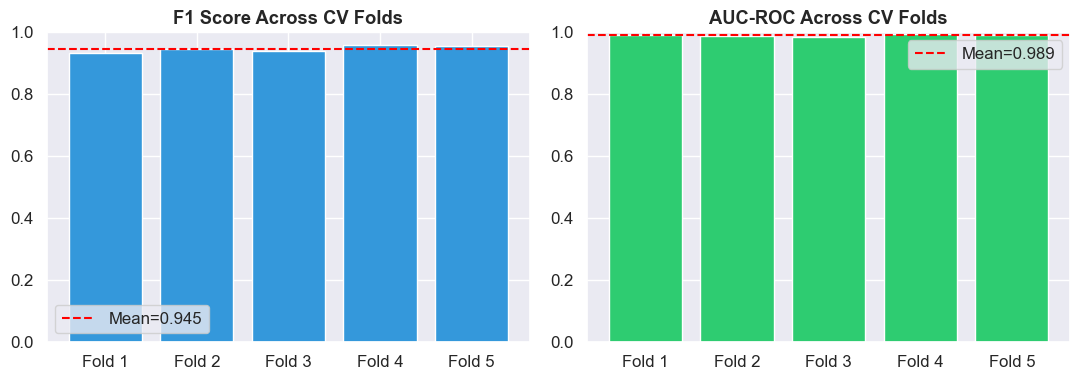

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1 = cross_val_score(baseline_model, X_train, y_train, cv=cv, scoring='f1')
cv_auc = cross_val_score(baseline_model, X_train, y_train, cv=cv, scoring='roc_auc')

print('5-Fold Cross-Validation Results (on training data):')
print(f'\n  F1 Score per fold:   {[round(x, 3) for x in cv_f1]}')
print(f'  Mean F1:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'\n  AUC-ROC per fold:    {[round(x, 3) for x in cv_auc]}')
print(f'  Mean AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'\nLow standard deviation = model is stable across different data splits.')

# Visualise CV scores
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
folds = [f'Fold {i+1}' for i in range(5)]
axes[0].bar(folds, cv_f1, color='#3498db', edgecolor='white')
axes[0].axhline(cv_f1.mean(), color='red', linestyle='--', label=f'Mean={cv_f1.mean():.3f}')
axes[0].set_title('F1 Score Across CV Folds', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[1].bar(folds, cv_auc, color='#2ecc71', edgecolor='white')
axes[1].axhline(cv_auc.mean(), color='red', linestyle='--', label=f'Mean={cv_auc.mean():.3f}')
axes[1].set_title('AUC-ROC Across CV Folds', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.savefig('../reports/10_cross_validation.png', bbox_inches='tight')
plt.show()

In [20]:
# Define the parameter grid to search
param_grid = {
    'n_estimators':  [100, 200, 300],      
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],   
    'subsample':     [0.8, 1.0],          
}

print(f'Total combinations to try: {3*3*3*2} = 54')

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,    
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\nBest parameters found:')
for param, value in grid_search.best_params_.items():
    print(f'  {param}: {value}')
print(f'\nBest CV F1 score: {grid_search.best_score_:.4f}')

Total combinations to try: 54 = 54
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best parameters found:
  learning_rate: 0.2
  max_depth: 4
  n_estimators: 100
  subsample: 0.8

Best CV F1 score: 0.9471


In [9]:
# Use the best parameters from GridSearch
final_model = XGBClassifier(
    **grid_search.best_params_,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

print('Final tuned model trained!')
print(f'\nFinal Model Results:')
print(f'  F1 Score:  {f1_score(y_test, y_pred_final):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_final):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred_final):.4f}')
print(f'  AUC-ROC:   {roc_auc_score(y_test, y_prob_final):.4f}')
print(f'\nDetailed classification report:')
print(classification_report(y_test, y_pred_final, target_names=['Pass', 'At-Risk']))

Final tuned model trained!

Final Model Results:
  F1 Score:  0.7789
  Precision: 0.7551
  Recall:    0.8043
  AUC-ROC:   0.9665

Detailed classification report:
              precision    recall  f1-score   support

        Pass       0.94      0.93      0.93       163
     At-Risk       0.76      0.80      0.78        46

    accuracy                           0.90       209
   macro avg       0.85      0.87      0.86       209
weighted avg       0.90      0.90      0.90       209



##  Compare baseline vs tuned model

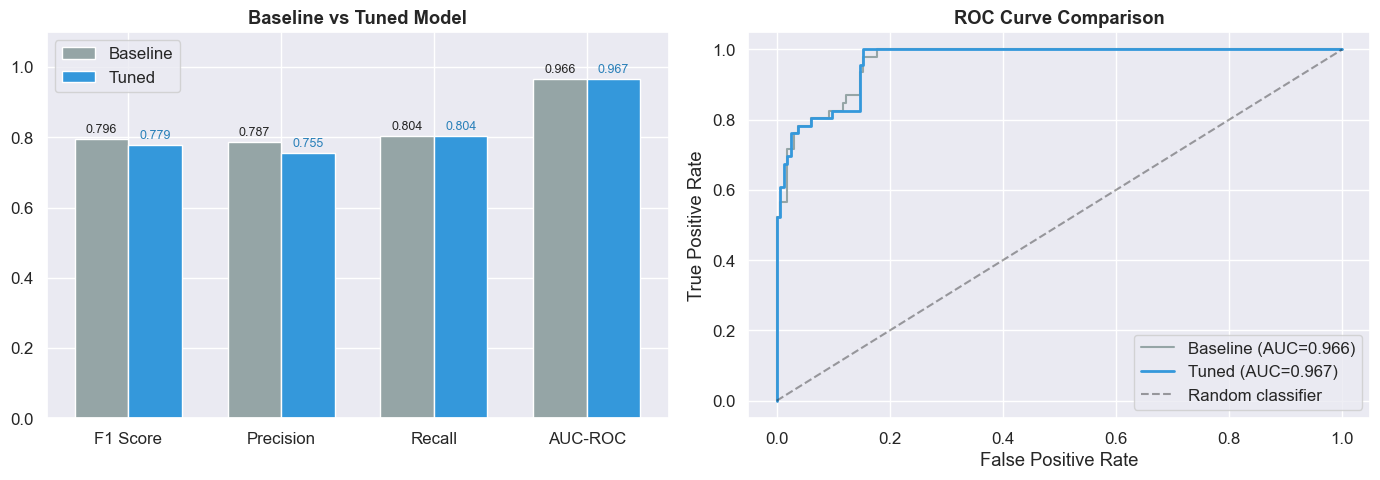

In [10]:
metrics = ['F1 Score', 'Precision', 'Recall', 'AUC-ROC']
baseline_scores = [
    f1_score(y_test, y_pred_baseline),
    precision_score(y_test, y_pred_baseline),
    recall_score(y_test, y_pred_baseline),
    roc_auc_score(y_test, y_prob_baseline)
]
final_scores = [
    f1_score(y_test, y_pred_final),
    precision_score(y_test, y_pred_final),
    recall_score(y_test, y_pred_final),
    roc_auc_score(y_test, y_prob_final)
]

x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(x - width/2, baseline_scores, width, label='Baseline', color='#95a5a6', edgecolor='white')
bars2 = axes[0].bar(x + width/2, final_scores, width, label='Tuned', color='#3498db', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Baseline vs Tuned Model', fontweight='bold')
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#2980b9')

# ROC Curve
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_baseline)
fpr_f, tpr_f, _ = roc_curve(y_test, y_prob_final)
axes[1].plot(fpr_b, tpr_b, color='#95a5a6', label=f'Baseline (AUC={roc_auc_score(y_test, y_prob_baseline):.3f})')
axes[1].plot(fpr_f, tpr_f, color='#3498db', linewidth=2, label=f'Tuned (AUC={roc_auc_score(y_test, y_prob_final):.3f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/11_baseline_vs_tuned.png', bbox_inches='tight')
plt.show()

## Confusion matrix of final model

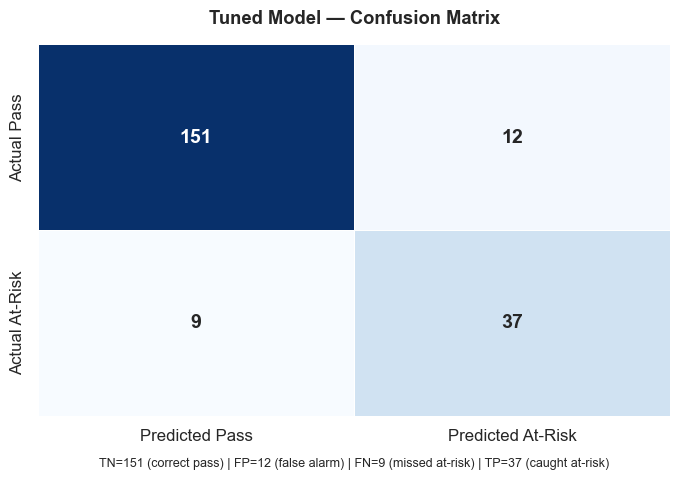

True Negatives  (correctly said pass):      151
False Positives (false alarm):              12
False Negatives (missed at-risk student):   9  ← key metric for FAILSAFE
True Positives  (correctly caught at-risk): 37

Of 46 real at-risk students in test set, we caught 37 (80.4%)


In [21]:
fig = plot_confusion_matrix(y_test, y_pred_final, 'Tuned Model — Confusion Matrix')
plt.savefig('../reports/12_confusion_matrix_final.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
print(f'True Negatives  (correctly said pass):      {tn}')
print(f'False Positives (false alarm):              {fp}')
print(f'False Negatives (missed at-risk student):   {fn}  ← key metric for FAILSAFE')
print(f'True Positives  (correctly caught at-risk): {tp}')
print(f'\nOf {sum(y_test==1)} real at-risk students in test set, we caught {tp} ({tp/sum(y_test==1)*100:.1f}%)')

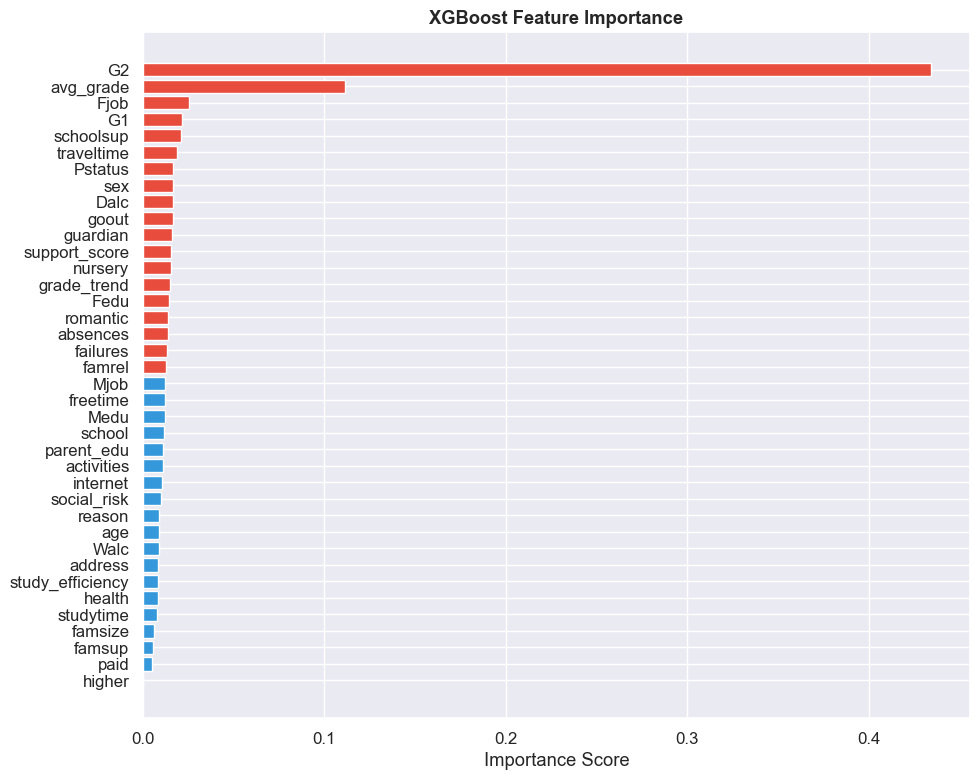

Top 5 most important features:
      feature  importance
15  schoolsup    0.020876
30         G1    0.021848
9        Fjob    0.025535
33  avg_grade    0.111289
31         G2    0.434308


In [12]:
feature_names = pd.read_csv('../data/processed/feature_names.csv').squeeze().tolist()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > importance_df['importance'].median() else '#3498db'
          for x in importance_df['importance']]
plt.barh(importance_df['feature'], importance_df['importance'],
         color=colors, edgecolor='white')
plt.title('XGBoost Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/13_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
print(importance_df.tail(5)[['feature','importance']].to_string())

In [22]:
# Save the trained model
joblib.dump(final_model, '../models/failsafe_model.pkl')

# Save model metadata
import json
metadata = {
    'model_type': 'XGBClassifier',
    'best_params': grid_search.best_params_,
    'test_metrics': {
        'f1':        round(f1_score(y_test, y_pred_final), 4),
        'precision': round(precision_score(y_test, y_pred_final), 4),
        'recall':    round(recall_score(y_test, y_pred_final), 4),
        'auc_roc':   round(roc_auc_score(y_test, y_prob_final), 4)
    },
    'n_features': X_train.shape[1],
    'training_samples': len(X_train),
    'feature_names': feature_names
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Model saved to models/failsafe_model.pkl')
print('Metadata saved to models/model_metadata.json')
print()
print(f'Final model F1:     {metadata["test_metrics"]["f1"]}')
print(f'Final model Recall: {metadata["test_metrics"]["recall"]}')
print(f'Final model AUC:    {metadata["test_metrics"]["auc_roc"]}')

Model saved to models/failsafe_model.pkl
Metadata saved to models/model_metadata.json

Final model F1:     0.7789
Final model Recall: 0.8043
Final model AUC:    0.9665
